# Neural Network signal vs. background

## INSTALLING THE REQUIRED DEPENDENCIES

Required python libraries (already installed in the dockerfile)

In [53]:
#!pip install numpy uproot scikit-learn matplotlib pandas seaborn tensorflow gdown

## START IMPORT

Importing the needed modules

In [4]:
import os
import sys
import time

import numpy as np
import uproot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_curve, roc_auc_score, f1_score, precision_score, classification_report, confusion_matrix)

import gdown

2026-06-30 13:46:09.705180: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-30 13:46:09.709761: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-30 13:46:09.749695: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-30 13:46:09.790931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782827169.843208     125 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782827169.85

## DATA PREPARATION

Downloading the dataset from Google Drive

In [3]:
file_id = "1LWOF7HsE8sJUUWZylVmuxRyKVr5Yyi_K"  # Google Drive file ID

gdown.download(
    id     = file_id,
    output = "SB_simul_down.root",
    quiet  = False
)

Downloading...
From (original): https://drive.google.com/uc?id=1LWOF7HsE8sJUUWZylVmuxRyKVr5Yyi_K
From (redirected): https://drive.google.com/uc?id=1LWOF7HsE8sJUUWZylVmuxRyKVr5Yyi_K&confirm=t&uuid=4a573b60-5b66-4768-b9c8-c501dbca8e08
To: /home/jovyan/SB_simul_down.root
100%|██████████| 2.25G/2.25G [04:05<00:00, 9.18MB/s]


'SB_simul_down.root'

In [56]:
# ROOT file path
file1_path = 'SB_simul.root'

# tree names
treeS_name = "TreeS"
treeB_name = "TreeB"

### Load data

In [57]:
# Loading data
file1 = uproot.open(file1_path)

# check the path
file1_path

'SB_simul.root'

In [83]:
# Extract signal and background trees
treeS = file1[treeS_name]
treeB = file1[treeB_name]

# Print what imported
print(treeS)
print(treeB)

<TTree 'TreeS' (13 branches) at 0x7f302b1c72c0>
<TTree 'TreeB' (13 branches) at 0x7f302b1c5ac0>


In [85]:
treeS.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
massK0S              | float                    | AsDtype('>f4')
tImpParBach          | float                    | AsDtype('>f4')
tImpParV0            | float                    | AsDtype('>f4')
CtK0S                | float                    | AsDtype('>f4')
cosPAK0S             | float                    | AsDtype('>f4')
nSigmapr             | float                    | AsDtype('>f4')
dcaV0                | float                    | AsDtype('>f4')
bachelorPt           | float                    | AsDtype('>f4')
v0Pt                 | float                    | AsDtype('>f4')
massLc2K0Sp          | float                    | AsDtype('>f4')
LcPt                 | float                    | AsDtype('>f4')
origin               | float                    | AsDtype('>f4')
asymmPt              | float                    | AsDtype(

In [60]:
treeB.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
massK0S              | float                    | AsDtype('>f4')
tImpParBach          | float                    | AsDtype('>f4')
tImpParV0            | float                    | AsDtype('>f4')
CtK0S                | float                    | AsDtype('>f4')
cosPAK0S             | float                    | AsDtype('>f4')
nSigmapr             | float                    | AsDtype('>f4')
dcaV0                | float                    | AsDtype('>f4')
bachelorPt           | float                    | AsDtype('>f4')
v0Pt                 | float                    | AsDtype('>f4')
massLc2K0Sp          | float                    | AsDtype('>f4')
LcPt                 | float                    | AsDtype('>f4')
origin               | float                    | AsDtype('>f4')
asymmPt              | float                    | AsDtype(

#### Load data from Trees into Pandas DataFrames (df)

In [76]:
df_signal = treeS.arrays(library = "pd")

df_signal

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0,bachelorPt,v0Pt,massLc2K0Sp,LcPt,origin,asymmPt
0,0.501015,0.002563,-0.018624,1.561310,0.999881,1.379819,0.012402,1.494723,0.657968,2.289467,1.287097,5.0,0.388702
1,0.498554,0.006365,0.429775,3.831764,0.997924,0.202202,0.078762,1.148710,0.863184,2.290424,1.326933,5.0,0.141919
2,0.499140,0.043404,-0.019748,1.008557,0.999953,0.394361,0.007458,1.071459,1.261988,2.288031,1.621147,5.0,-0.081651
3,0.492339,-0.000342,0.011495,0.367885,0.999529,1.677530,0.009267,1.068153,1.007324,2.277980,1.273440,5.0,0.029308
4,0.496173,-0.073643,0.246707,3.753914,0.999609,1.095001,0.920251,0.723837,1.323777,2.285922,1.706256,5.0,-0.292995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
943640,0.499240,0.004190,0.027761,0.570992,0.999818,0.991573,0.026876,0.916397,1.278712,2.281716,1.491507,5.0,-0.165056
943641,0.500042,-0.000711,0.290690,10.120708,0.999901,1.864643,0.579110,1.081626,1.002655,2.286515,1.131780,5.0,0.037889
943642,0.497493,-0.053349,0.056918,3.069903,0.999974,-0.995700,0.011193,0.628474,1.110416,2.286527,1.227481,5.0,-0.277155
943643,0.501001,0.005253,0.020308,0.980737,0.999701,-1.666190,0.028961,1.637398,0.561509,2.276654,1.375886,5.0,0.489284


In [77]:
df_background = treeB.arrays(library = "pd")

df_background

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0,bachelorPt,v0Pt,massLc2K0Sp,LcPt,origin,asymmPt
0,0.497245,-0.043013,-0.004528,2.556512,0.999998,-0.452066,0.017104,0.420924,1.747855,2.462304,1.429823,-1.0,-0.611834
1,0.497012,0.005981,-0.025221,1.455961,0.999940,0.187446,0.009095,0.494504,1.245030,2.165277,1.040291,-1.0,-0.431453
2,0.505080,0.022939,-0.003785,0.080898,0.996212,0.460292,0.031412,0.572067,1.356922,2.124467,1.790542,-1.0,-0.406873
3,0.499342,-0.008351,-0.010375,1.467479,0.999989,1.402289,0.001994,1.369383,0.834325,2.105740,1.957422,-1.0,0.242799
4,0.494041,-0.006271,-0.001192,0.447153,0.999125,-1.857860,0.052720,1.347346,0.681790,2.213034,1.508441,-1.0,0.328000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26849768,0.488910,0.206418,0.089082,1.124604,0.998503,-0.200791,0.229895,1.416834,0.755706,2.316674,1.212868,-1.0,0.304311
26849769,0.494111,0.000832,-0.007204,0.439936,0.999581,0.383316,0.064410,1.401958,0.534967,2.156958,1.228046,-1.0,0.447612
26849770,0.504458,0.167190,0.112703,35.785530,0.999968,-0.481222,1.211956,1.544939,0.706098,2.217232,1.598873,-1.0,0.372647
26849771,0.503800,0.003915,-0.840921,72.546837,0.996647,-2.491238,1.239423,1.400697,0.799472,2.255564,1.357744,-1.0,0.273263


### Prepare data
Prepare data for the training and evaluation of a classification model.

In [78]:
feature_names = ["massK0S",
                 "tImpParBach",
                 "tImpParV0",
                 "CtK0S",
                 "cosPAK0S",
                 "nSigmapr",
                 "dcaV0"]

feature_names

['massK0S',
 'tImpParBach',
 'tImpParV0',
 'CtK0S',
 'cosPAK0S',
 'nSigmapr',
 'dcaV0']

#### Select features


In [64]:
X_signal = df_signal[feature_names]

X_signal

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.501015,0.002563,-0.018624,1.561310,0.999881,1.379819,0.012402
1,0.498554,0.006365,0.429775,3.831764,0.997924,0.202202,0.078762
2,0.499140,0.043404,-0.019748,1.008557,0.999953,0.394361,0.007458
3,0.492339,-0.000342,0.011495,0.367885,0.999529,1.677530,0.009267
4,0.496173,-0.073643,0.246707,3.753914,0.999609,1.095001,0.920251
...,...,...,...,...,...,...,...
943640,0.499240,0.004190,0.027761,0.570992,0.999818,0.991573,0.026876
943641,0.500042,-0.000711,0.290690,10.120708,0.999901,1.864643,0.579110
943642,0.497493,-0.053349,0.056918,3.069903,0.999974,-0.995700,0.011193
943643,0.501001,0.005253,0.020308,0.980737,0.999701,-1.666190,0.028961


In [65]:
X_background = df_background[feature_names]

X_background

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.497245,-0.043013,-0.004528,2.556512,0.999998,-0.452066,0.017104
1,0.497012,0.005981,-0.025221,1.455961,0.999940,0.187446,0.009095
2,0.505080,0.022939,-0.003785,0.080898,0.996212,0.460292,0.031412
3,0.499342,-0.008351,-0.010375,1.467479,0.999989,1.402289,0.001994
4,0.494041,-0.006271,-0.001192,0.447153,0.999125,-1.857860,0.052720
...,...,...,...,...,...,...,...
26849768,0.488910,0.206418,0.089082,1.124604,0.998503,-0.200791,0.229895
26849769,0.494111,0.000832,-0.007204,0.439936,0.999581,0.383316,0.064410
26849770,0.504458,0.167190,0.112703,35.785530,0.999968,-0.481222,1.211956
26849771,0.503800,0.003915,-0.840921,72.546837,0.996647,-2.491238,1.239423


#### Start Normalisation

Normalize SIGNAL dataset by dividing by the maximum value of each variable

In [ ]:
# Take the max
max_massK0S_signal     = X_signal["massK0S"].max()
max_tImpParBach_signal = X_signal["tImpParBach"].max()
max_tImpParV0_signal   = X_signal["tImpParV0"].max()
max_CtK0S_signal       = X_signal["CtK0S"].max()
max_cosPAK0S_signal    = X_signal["cosPAK0S"].max()
max_nSigmapr_signal    = X_signal["nSigmapr"].max()
max_dcaV0_signal       = X_signal["dcaV0"].max()

X_signal_normalized = pd.DataFrame()

# Divide_signal
X_signal_normalized["massK0S"]     = X_signal["massK0S"]     / max_massK0S_signal
X_signal_normalized["tImpParBach"] = X_signal["tImpParBach"] / max_tImpParBach_signal
X_signal_normalized["tImpParV0"]   = X_signal["tImpParV0"]   / max_tImpParV0_signal
X_signal_normalized["CtK0S"]       = X_signal["CtK0S"]       / max_CtK0S_signal
X_signal_normalized["cosPAK0S"]    = X_signal["cosPAK0S"]    / max_cosPAK0S_signal
X_signal_normalized["nSigmapr"]    = X_signal["nSigmapr"]    / max_nSigmapr_signal
X_signal_normalized["dcaV0"]       = X_signal["dcaV0"]       / max_dcaV0_signal

X_signal_normalized

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.987000,0.005126,-0.012468,0.015291,0.999881,0.330775,0.008268
1,0.982152,0.012732,0.287732,0.037526,0.997924,0.048472,0.052508
2,0.983307,0.086824,-0.013221,0.009877,0.999953,0.094537,0.004972
3,0.969909,-0.000684,0.007696,0.003603,0.999529,0.402143,0.006178
4,0.977463,-0.147312,0.165169,0.036764,0.999609,0.262497,0.613505
...,...,...,...,...,...,...,...
943640,0.983504,0.008381,0.018586,0.005592,0.999818,0.237703,0.017918
943641,0.985084,-0.001423,0.194616,0.099116,0.999901,0.446998,0.386076
943642,0.980062,-0.106716,0.038107,0.030065,0.999974,-0.238692,0.007462
943643,0.986973,0.010507,0.013596,0.009605,0.999701,-0.399424,0.019308


Normalize BACKGROUND dataset by dividing by the maximum value of each variable

In [ ]:
# Take the max
max_massK0S_background     = X_background["massK0S"].max()
max_tImpParBach_background = X_background["tImpParBach"].max()
max_tImpParV0_background   = X_background["tImpParV0"].max()
max_CtK0S_background       = X_background["CtK0S"].max()
max_cosPAK0S_background    = X_background["cosPAK0S"].max()
max_nSigmapr_background    = X_background["nSigmapr"].max()
max_dcaV0_background       = X_background["dcaV0"].max()

X_background_normalized = pd.DataFrame()

# Divide_background
X_background_normalized["massK0S"]     = X_background["massK0S"]     / max_massK0S_background
X_background_normalized["tImpParBach"] = X_background["tImpParBach"] / max_tImpParBach_background
X_background_normalized["tImpParV0"]   = X_background["tImpParV0"]   / max_tImpParV0_background
X_background_normalized["CtK0S"]       = X_background["CtK0S"]       / max_CtK0S_background
X_background_normalized["cosPAK0S"]    = X_background["cosPAK0S"]    / max_cosPAK0S_background
X_background_normalized["nSigmapr"]    = X_background["nSigmapr"]    / max_nSigmapr_background
X_background_normalized["dcaV0"]       = X_background["dcaV0"]       / max_dcaV0_background

X_background_normalized

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.979572,-0.086025,-0.003019,0.007670,0.999998,-0.106729,0.011402
1,0.979115,0.011961,-0.016814,0.004368,0.999940,0.044254,0.006064
2,0.995008,0.045878,-0.002523,0.000243,0.996212,0.108671,0.020942
3,0.983705,-0.016702,-0.006916,0.004403,0.999989,0.331068,0.001330
4,0.973262,-0.012541,-0.000794,0.001342,0.999125,-0.438624,0.035147
...,...,...,...,...,...,...,...
26849768,0.963154,0.412837,0.059388,0.003374,0.998503,-0.047405,0.153263
26849769,0.973400,0.001664,-0.004803,0.001320,0.999581,0.090497,0.042940
26849770,0.993783,0.334381,0.075135,0.107362,0.999968,-0.113612,0.807971
26849771,0.992487,0.007830,-0.560614,0.217651,0.996647,-0.588159,0.826282


Truncate the BACKGROUND dataset to match the same number of events of the SIGNAL one

In [68]:
bkg_max = 943645

X_background_normalized[:bkg_max]

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.979572,-0.086025,-0.003019,0.007670,0.999998,-0.106729,0.011402
1,0.979115,0.011961,-0.016814,0.004368,0.999940,0.044254,0.006064
2,0.995008,0.045878,-0.002523,0.000243,0.996212,0.108671,0.020942
3,0.983705,-0.016702,-0.006916,0.004403,0.999989,0.331068,0.001330
4,0.973262,-0.012541,-0.000794,0.001342,0.999125,-0.438624,0.035147
...,...,...,...,...,...,...,...
943640,0.972058,0.007930,-0.001359,0.003570,0.999995,-0.516423,0.001118
943641,0.961141,0.019267,0.032449,0.007391,0.999983,0.057793,0.017136
943642,0.980433,-0.003765,-0.155868,0.011146,0.994395,0.348513,0.189550
943643,0.966688,-0.004010,0.037481,0.013495,0.998602,0.126529,0.788198


Concatenate normalized DataFrames (limiting the amount of bkg)

In [87]:
X = pd.concat([X_signal_normalized,
               X_background_normalized[:bkg_max]])

X

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
0,0.987000,0.005126,-0.012468,0.015291,0.999881,0.330775,0.008268
1,0.982152,0.012732,0.287732,0.037526,0.997924,0.048472,0.052508
2,0.983307,0.086824,-0.013221,0.009877,0.999953,0.094537,0.004972
3,0.969909,-0.000684,0.007696,0.003603,0.999529,0.402143,0.006178
4,0.977463,-0.147312,0.165169,0.036764,0.999609,0.262497,0.613505
...,...,...,...,...,...,...,...
943640,0.972058,0.007930,-0.001359,0.003570,0.999995,-0.516423,0.001118
943641,0.961141,0.019267,0.032449,0.007391,0.999983,0.057793,0.017136
943642,0.980433,-0.003765,-0.155868,0.011146,0.994395,0.348513,0.189550
943643,0.966688,-0.004010,0.037481,0.013495,0.998602,0.126529,0.788198


Add a "target" column to distinguish signal (1) from background (0)

In [70]:
y = np.concatenate([np.ones(len(X_signal_normalized)),
                    np.zeros(len(X_background_normalized[:bkg_max]))])

y

array([1., 1., 1., ..., 0., 0., 0.])

Split data into training and test sets (```test_size = 0.2```)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size    = 0.2,
    random_state = 42,
    shuffle      = True
)

In [72]:
X_train

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
268244,0.995745,-0.238274,-0.347419,0.191465,0.995270,0.106780,0.304693
735762,0.982707,0.026833,-0.008591,0.001153,0.997953,-0.412503,0.000316
328941,0.977442,0.007475,0.017322,0.006129,0.999981,-0.637929,0.010743
825003,0.982712,-0.009235,-0.057571,0.033864,0.999946,0.212708,0.040910
563920,0.971694,-0.346275,0.000370,0.000830,0.999999,-0.119077,0.005468
...,...,...,...,...,...,...,...
259178,0.980911,0.023027,-0.048947,0.020316,0.999776,-0.075100,0.052283
470769,0.980080,-0.016741,0.076019,0.260445,0.999747,-0.368146,0.082689
131932,0.986179,-0.042296,-0.002482,0.012904,0.999933,0.482583,0.007430
671155,0.982747,0.004448,0.002653,0.029530,0.999986,0.372015,0.006336


In [73]:
y_train

array([0., 1., 0., ..., 1., 1., 1.])

In [74]:
X_test

,massK0S,tImpParBach,tImpParV0,CtK0S,cosPAK0S,nSigmapr,dcaV0
440066,0.982498,-0.028773,0.006672,0.004373,0.999961,-0.485777,0.005445
641690,0.982248,0.002584,0.131174,0.024346,0.999919,-0.674713,0.180905
895587,0.972896,0.090752,0.546962,0.025393,0.999334,0.420881,0.175494
716902,0.978545,-0.022545,0.002682,0.004919,0.999833,0.011274,0.006148
825156,0.974104,-0.023232,-0.010898,0.007823,0.999905,0.196119,0.000409
...,...,...,...,...,...,...,...
372169,0.986119,-0.019075,0.022880,0.016377,0.999940,0.134576,0.005848
112632,0.993161,-0.245236,0.200003,0.046936,0.999660,0.164171,0.189549
562077,0.985509,-0.218995,0.039473,0.054910,0.999982,0.007552,0.030837
748572,0.981175,0.002918,-0.283516,0.047563,0.999909,-0.601762,0.565781


In [75]:
y_test

array([1., 0., 0., ..., 1., 0., 0.])

## MODEL DEFINITION

In [52]:
X_train.shape[1]

7

In [ ]:
neurons = 32
drop_out = 0.2
learning_rate = 0.001

# neurons = 64
# drop_out = 0.3
# learning_rate = 0.001

model = keras.Sequential(
    [
        layers.Input(
            shape = (X_train.shape[1],)
        ),  # layer di input, shape è dimensione dei dati
        layers.Dense(
            neurons,
            activation = "relu"
        ),  # layer collegati a tutti i neuroni
        layers.Dropout(
            drop_out
        ),  # spegne un tot di neuroni per non influenzare troppo la rete
        layers.Dense(
            neurons,
            activation = "relu"),
        layers.Dropout(
            drop_out),
        layers.Dense(1,
                     activation = "sigmoid")])

model

<Sequential name=sequential_10, built=True>

In [99]:
model.compile(optimizer = keras.optimizers.Adam(learning_rate = learning_rate),  # usa optimizer Adam,
              loss      = "binary_crossentropy",
              metrics   = ["accuracy",
                           keras.metrics.Precision(),
                           keras.metrics.Recall(),
                          ])

model

<Sequential name=sequential_8, built=True>

In [102]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Network diagram

In [115]:
plot_model = tf.keras.utils.plot_model(
    model,
    to_file="model.pdf",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=50,
    show_layer_activations=True,
    show_trainable=True,
)

plot_model

## TRAINING OF THE MODEL

In [26]:
%%time

# Start measuring time
start_time = time.time()

# funzione fondamentale con cui viene allenato il modello model.fit
history = model.fit(X_train,
                    y_train,
                    epochs           = 10,
                    batch_size       = 32,
                    validation_split = 0.2)
# DIVIDE TRAIN TRA TRAIN E VALIDATION validation_split=0.2

# Calculates the elapsed time for training
training_time = time.time() - start_time

Epoch 1/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 687us/step - accuracy: 0.7698 - loss: 0.4627 - precision: 0.7712 - recall: 0.7726 - val_accuracy: 0.8112 - val_loss: 0.3953 - val_precision: 0.8510 - val_recall: 0.7546
Epoch 2/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 715us/step - accuracy: 0.8056 - loss: 0.4093 - precision: 0.8262 - recall: 0.7728 - val_accuracy: 0.8117 - val_loss: 0.3961 - val_precision: 0.8468 - val_recall: 0.7613
Epoch 3/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 720us/step - accuracy: 0.8072 - loss: 0.4061 - precision: 0.8283 - recall: 0.7748 - val_accuracy: 0.8129 - val_loss: 0.3921 - val_precision: 0.8555 - val_recall: 0.7531
Epoch 4/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 710us/step - accuracy: 0.8081 - loss: 0.4049 - precision: 0.8287 - recall: 0.7770 - val_accuracy: 0.8109 - val_loss: 0.3944 - val_precision: 0.8679 - val_recall: 0.7335
Epoch 5/10
37746/37746 ━━━━━━━━━━━━━━━━━━━━ 27s 722us/step - accuracy: 0.8085 - loss: 0.4040 - precision: 0.8289 - recall: 0.7771 - 

## EVALUATION

In [27]:
probability = model.predict(X_test)

11796/11796 ━━━━━━━━━━━━━━━━━━━━ 3s 279us/step


In [28]:
# Calculate predicted probabilities for the positive class for the two cases
predictions = (probability > 0.5).astype(int)

print(predictions)

[[0]
 [0]
 [0]
 ...
 [1]
 [0]
 [0]]


### Calculate the ROC curve

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, probability)
roc_auc              = roc_auc_score(y_test, probability)

In [30]:
print(fpr)

[0.        0.        0.        ... 0.994825  0.9948356 1.       ]


In [31]:
print(tpr)

[0.00000000e+00 5.29495550e-06 1.58848665e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]


In [32]:
print(thresholds)

[          inf 9.9381858e-01 9.9228960e-01 ... 4.7398353e-06 4.7375261e-06
 7.6931777e-09]


In [33]:
print(roc_auc)

0.9053065901442087


### Calculate model accuracy, f1_score & precision

In [34]:
# Full dataset
accuracy  = accuracy_score(y_test,  predictions)
f1        = f1_score(y_test,        predictions)
precision = precision_score(y_test, predictions)

In [35]:
print(accuracy)

0.8164246088306514


In [36]:
print(f1)

0.8111461183729981


In [37]:
print(precision)

0.8357699285028278


In [38]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.80      0.84      0.82    188599
         1.0       0.84      0.79      0.81    188859

    accuracy                           0.82    377458
   macro avg       0.82      0.82      0.82    377458
weighted avg       0.82      0.82      0.82    377458



### Additional evaluation

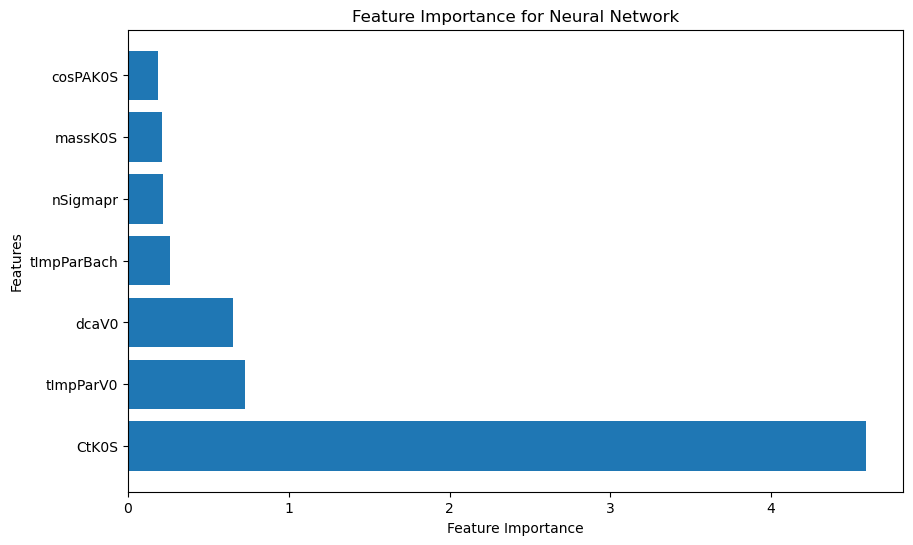

In [39]:
# Calculate feature importance for Neural Network model
weights         = np.abs(model.get_weights()[0]).mean(axis=1)
sorted_indices  = np.argsort(weights)[::-1]
sorted_features = [feature_names[i] for i in sorted_indices]
sorted_weights  = weights[sorted_indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features,
         sorted_weights)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Neural Network")

#plt.show()
plt.savefig("evaluation_results/feature_importance_Neural_Network.svg")

In [40]:
print(sorted_weights)

[4.5915604  0.7248768  0.65411294 0.26166993 0.216037   0.21278733
 0.18856886]


## PRINT RESULTS

In [50]:
# Define the folder path
folder1_path = "evaluation_results"

folder1_path

'evaluation_results'

In [ ]:
# Define the full path of the output file
output_file = os.path.join(folder1_path, "NN" + ".txt")

# It is necessary to create the output file required for the Metrics module
with open(output_file, "w") as f:
    f.write("accuracy:  {}\n".format(accuracy))  # Accuracy  result
    f.write("f1 score:  {}\n".format(f1))        # f1_score  result
    f.write("precision: {}\n".format(precision)) # precision result
    f.write("ROC AUC:   {}\n".format(roc_auc))   # roc auc   result
    f.write("fpr\ttpr\n")  # Printing of TPR and FPR data for ROC plot.
    for i in range(len(fpr)):
        f.write("{}\t{}\n".format(fpr[i], tpr[i]))

print(output_file)

### Metrics display

#### ROC curve

In [43]:
# Calculate background rejection (1 - FPR)
background_rejection = 1 - fpr

print(background_rejection)

[1.        1.        1.        ... 0.005175  0.0051644 0.       ]


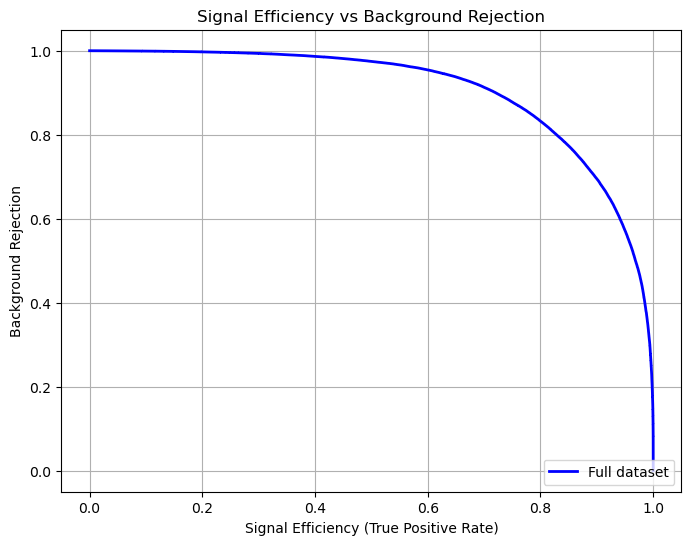

In [44]:
# Plot signal efficiency vs background rejection
plt.figure(figsize=(8, 6))
plt.plot(tpr,
         background_rejection,
         color = "blue",
         lw    = 2,
         label = "Full dataset")
plt.xlabel("Signal Efficiency (True Positive Rate)")
plt.ylabel("Background Rejection")
plt.title("Signal Efficiency vs Background Rejection")
plt.legend(loc="lower right")
plt.grid(True)

#plt.show()
plt.savefig("evaluation_results/roc_curve.svg")

#### Print metrics

In [45]:
print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Precision:", precision)

print("ROC AUC:  ", roc_auc)

Accuracy:  0.8164246088306514
F1 Score:  0.8111461183729981
Precision: 0.8357699285028278
ROC AUC:   0.9053065901442087


#### Confusion Matrix (CM)

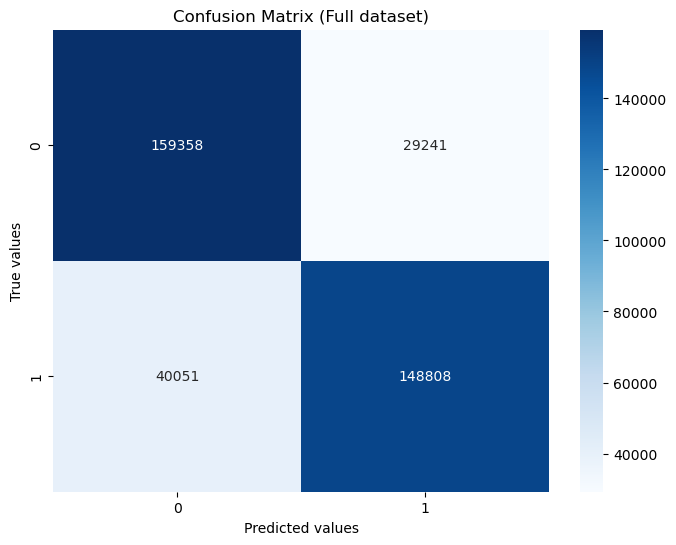

In [46]:
cm = confusion_matrix(y_test,
                      predictions)

# Visualize Confusion Matrix
plt.figure(figsize = (8, 6))
sns.heatmap(cm,
            annot  = True,
            fmt    = "d",
            cmap   = "Blues")
plt.title("Confusion Matrix (Full dataset)")
plt.xlabel("Predicted values")
plt.ylabel("True values")

# plt.show()
plt.savefig("evaluation_results/confusion_matrix.svg")

#### Metrics during epochs

In [47]:
print(model)

<Sequential name=sequential, built=True>


In [48]:
print(history)

In [49]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


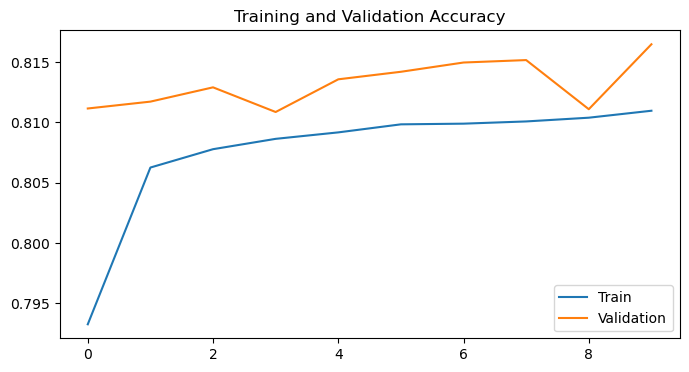

In [50]:
acc = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(8, 4))
plt.plot(range(len(acc)), acc, label='Train')
plt.plot(range(len(val_accuracy)), val_accuracy, label='Validation')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.show()

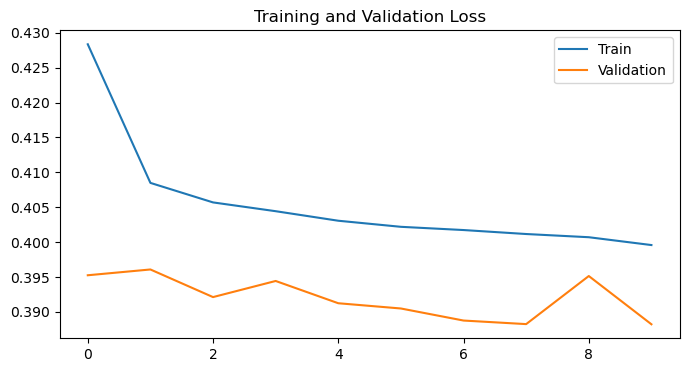

In [51]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 4))
plt.plot(range(len(loss)), loss, label='Train')
plt.plot(range(len(val_loss)), val_loss, label='Validation')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [52]:
# f1_score = 2 * (precision * recall) / (precision + recall)

precision = np.array(history.history['precision'])
recall = np.array(history.history['recall'])

f1_score = 2 * (precision * recall) / (precision + recall)

print(f1_score)

[0.7884301  0.79988026 0.80141947 0.80246878 0.80289186 0.80360763
 0.80371345 0.80379726 0.80415502 0.80482933]


In [53]:
val_precision = np.array(history.history['val_precision'])
val_recall = np.array(history.history['val_recall'])

val_f1_score = 2 * (val_precision * val_recall) / (val_precision + val_recall)

print(val_f1_score)

[0.79986944 0.80177402 0.80105502 0.79504478 0.8074933  0.80914671
 0.81160985 0.81141811 0.79476127 0.81094453]


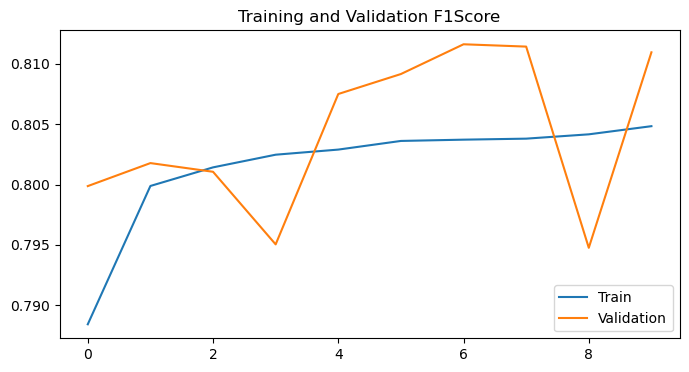

In [54]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(f1_score)), f1_score, label='Train')
plt.plot(range(len(val_f1_score)), val_f1_score, label='Validation')
plt.legend(loc='lower right')
plt.title('Training and Validation F1Score')

plt.show()